## Random Forest

- Forest comes to solve one big problem of trees flexibility they tends to overfit the data and becomes inaccurate when they encounter new data
- Random forest combines simplicity of decision tree with flexibility resulting in vast improvement in accuracy.

### How it works ?

- We train random forest on bootstrap dataset (training data), So first we create bootstrap dataset.
- Then we create a decision tree on random subset of features (or columns) at each step. Then select feature which did best job at separating data and choose that feature.
- Then we repeat this process 100's of times to create random forest model fitted to given dataset.

### How it makes prediction ?

- First we pass that instant on which prediction is to be made through all the trees in forest and take vote from each tree on one option and we will see at last which option received most vote. Option which received most vote is our prediction for that instant.

### Accuracy of random forest

- We use test dataset or dataset on which model is not been trained on and check how many of them model got correct answer for and the ratio of correct to total datapoints is the accuracy of that model.

### Why Deep trees ?

- A Random Forest is a bagged ensemble of deep decision trees, trained on bootstrap samples, with random feature selection at each split.
- Deep trees have low bias and high variance. we use deep trees due to its low bias as its variance decreases by factor of 1 / n_trees in random forest if trees are uncorrelated as they should be because if they are correlated their is no gain in it.

### Random Forest Regressor

In [1]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

x, y = make_regression(n_samples=100, n_features=3, n_informative=3, noise=0.1, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [2]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_leaf=1, max_features="sqrt", bootstrap=True, random_state=42)
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [3]:
print("Model Score on Training set :", model.score(x_train, y_train))
print("Model Score on Testing set :", model.score(x_test, y_test))

Model Score on Training set : 0.9765451429880694
Model Score on Testing set : 0.6797867478963331


As you can see model's score or accuracy on training set is very high as it bias is very low as we have discussed in "why deep tree ?" section but as our data set is very small we get only ~0.67 score but that is not that bad and we can predict the correct values of an unseen instant on our model more than 50% of time. 

### Gini importance

In [4]:
model.feature_importances_

array([0.20523881, 0.60810837, 0.18665282])

- This is Gini importance of model trained on given data this number say that feature2 contributes most in reducing impurity across all tree.
- It shows that which features are more important and which are less important.
- Caution we cannot 100% trust gini impurity because it will be higher of feature with high cardinality (feature with many distinct values) even though it is weak in splitting the data.

## Bias-Variance tradeoff in Random Forest Regressor

In [5]:
from sklearn.datasets import make_regression

x, y = make_regression(n_samples=1000, n_features=3, n_informative=3, noise=0.1, random_state=42)   

In [6]:
import numpy as np
from sklearn.model_selection import train_test_split

def bias_variance_of_random_forest(x, y, n_estimators=200, n_rounds=100):
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    
    predictions = []
    
    for _ in range(n_rounds):
        
        idx = np.random.choice(len(x_train), len(x_train), replace=True)
        x_boot = x_train[idx]
        y_boot = y_train[idx]
        
        model = RandomForestRegressor(n_estimators=n_estimators, max_depth=None, min_samples_leaf=1, max_features="sqrt", bootstrap=True, random_state=42)
        model.fit(x_boot, y_boot)
        
        predictions.append(model.predict(x_test))
        
    predictions = np.array(predictions)
    
    avg_prediction = predictions.mean(axis=0)
    
    bias2 = np.mean((avg_prediction - y_test) ** 2)
    
    variance = np.mean(np.var(predictions, axis=0))
    
    return bias2, variance

In [7]:
from sklearn.tree import DecisionTreeRegressor

def bias_variance_of_decision_tree(x, y, max_depth=None, n_rounds=100):
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    
    predictions = []
    
    for _ in range(n_rounds):
        
        idx = np.random.choice(len(x_train), len(x_train), replace=True)
        x_boot = x_train[idx]
        y_boot = y_train[idx]
        
        model = DecisionTreeRegressor(max_depth=max_depth, random_state=42)
        model.fit(x_boot, y_boot)
        
        predictions.append(model.predict(x_test))
        
    predictions = np.array(predictions)
    
    avg_prediction = predictions.mean(axis=0)
    
    bias2 = np.mean((avg_prediction - y_test) ** 2)
    
    variance = np.mean(np.var(predictions, axis=0))
    
    return bias2, variance

In [8]:
rf_bias , rf_variance = bias_variance_of_random_forest(x, y)
tree_bias , tree_variance = bias_variance_of_decision_tree(x, y)

In [9]:
print(rf_variance)
print(tree_variance)
print(rf_bias)
print(tree_bias)

99.91559060635208
821.7270027593622
824.7461878481643
354.8660848085156


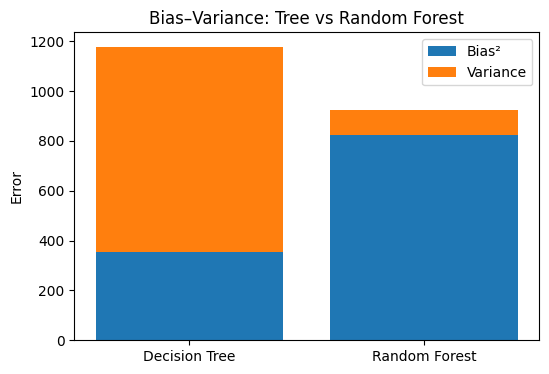

In [10]:
models = ["Decision Tree", "Random Forest"]
biases = [tree_bias, rf_bias]
variances = [tree_variance, rf_variance]

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(models, biases, label="Bias²")
plt.bar(models, variances, bottom=biases, label="Variance")
plt.ylabel("Error")
plt.title("Bias–Variance: Tree vs Random Forest")
plt.legend()
plt.show()


## Bias-Variance tradeoff in Random Forest Classifier

In [11]:
from sklearn.datasets import make_classification

x, y = make_classification(n_samples=1000, n_features=3, n_classes=2, n_informative=3, n_redundant=0, random_state=42)   

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

def bias_variance_of_random_forest(x, y, n_estimators=200, n_rounds=100):
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    
    predictions = []
    
    for _ in range(n_rounds):
        
        idx = np.random.choice(len(x_train), len(x_train), replace=True)
        x_boot = x_train[idx]
        y_boot = y_train[idx]
        
        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=None, min_samples_leaf=1, max_features="sqrt", bootstrap=True, random_state=42)
        model.fit(x_boot, y_boot)
        
        predictions.append(model.predict(x_test))
        
    predictions = np.array(predictions)
    
    avg_prediction = predictions.mean(axis=0)
    
    bias2 = np.mean((avg_prediction - y_test) ** 2)
    
    variance = np.mean(np.var(predictions, axis=0))
    
    return bias2, variance

In [13]:
from sklearn.tree import DecisionTreeClassifier

def bias_variance_of_decision_tree(x, y, max_depth=None, n_rounds=100):
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    
    predictions = []
    
    for _ in range(n_rounds):
        
        idx = np.random.choice(len(x_train), len(x_train), replace=True)
        x_boot = x_train[idx]
        y_boot = y_train[idx]
        
        model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
        model.fit(x_boot, y_boot)
        
        predictions.append(model.predict(x_test))
        
    predictions = np.array(predictions)
    
    avg_prediction = predictions.mean(axis=0)
    
    bias2 = np.mean((avg_prediction - y_test) ** 2)
    
    variance = np.mean(np.var(predictions, axis=0))
    
    return bias2, variance

In [14]:
rf_bias , rf_variance = bias_variance_of_random_forest(x, y)
tree_bias , tree_variance = bias_variance_of_decision_tree(x, y)

In [15]:
print(rf_variance)
print(tree_variance)
print(rf_bias)
print(tree_bias)

0.014334500000000002
0.0395375
0.054515499999999995
0.0450125


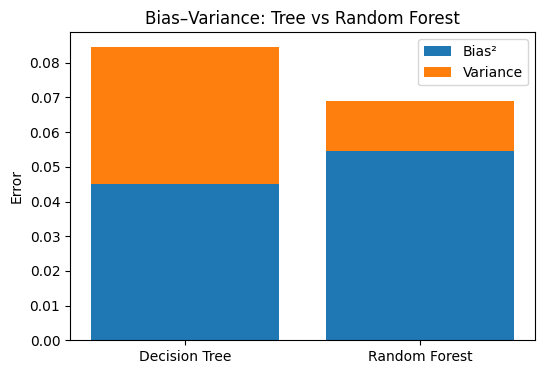

In [16]:
models = ["Decision Tree", "Random Forest"]
biases = [tree_bias, rf_bias]
variances = [tree_variance, rf_variance]

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(models, biases, label="Bias²")
plt.bar(models, variances, bottom=biases, label="Variance")
plt.ylabel("Error")
plt.title("Bias–Variance: Tree vs Random Forest")
plt.legend()
plt.show()
